# 2: Exploratory Data Analysis

This notebook explores the merged dataset and turns it into a set of readable descriptive findings. 


## 2.1 Setup and load the merged dataset

This section loads the merged dataset and prepares the figure output folder so the rest of the notebook can focus on analysis rather than file setup.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from matplotlib.ticker import PercentFormatter

NOTEBOOK_DIR = Path.cwd().resolve()
# Support running the notebook either inside notebooks/ or from the project root.
ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
# EDA always starts from the slim merged dataset created in notebook 01.
DATASET_PATH = ROOT / "data" / "processed" / "dataset_final.csv"
OUTPUTS_DIR = ROOT / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# A white grid theme keeps percentage plots readable without overwhelming the report figures.
sns.set_theme(style="whitegrid", context="talk")

print(f"Project root: {ROOT}")
print(f"Dataset path: {DATASET_PATH.relative_to(ROOT)}")
print(f"Figures directory: {FIGURES_DIR.relative_to(ROOT)}")


Project root: /Users/berenaydogan/Documents/4.2/DSA210/Project/DSA210-Project
Dataset path: data/processed/dataset_final.csv
Figures directory: outputs/figures


In [2]:
# Parse the key timestamp columns up front so temporal grouping and plotting use real datetimes.
date_columns = ["service_date", "scheduled_arrival", "weather_time"]

assert DATASET_PATH.exists(), "Run 01_data_collection.ipynb first so data/processed/dataset_final.csv exists."

df = pd.read_csv(DATASET_PATH, parse_dates=date_columns)
dataset_row_count = len(df)
dataset_column_count = len(df.columns)

season_order = [
    "Winter (Jan window)",
    "Spring (Apr window)",
    "Summer (Jul window)",
    "Autumn (Oct window)",
]
# Preserve the intended seasonal sequence instead of letting alphabetical sorting scramble the windows.
df["season_window"] = pd.Categorical(
    df["season_window"],
    categories=season_order,
    ordered=True,
)

# These checks confirm the merge notebook produced a fully labeled, analysis table with weather matched to every row.
assert df["season_window"].notna().all(), "Every row should map to a seasonal window."
assert df["weather_matched"].all(), "The merged dataset should have full weather coverage."

print(f"Loaded rows: {dataset_row_count:,}")
print(f"Loaded columns: {dataset_column_count:,}")
display(df.head())


Loaded rows: 90,818
Loaded columns: 21


,service_date,season_window,scheduled_arrival,scheduled_arrival_date,delay_minutes,delayed,scheduled_arrival_hour,scheduled_arrival_weekday,scheduled_arrival_weekday_name,scheduled_arrival_month,...,stop_name,train_type,line_name,operator,weather_time,temperature_2m,precipitation,snowfall,wind_speed_10m,weather_matched
0,2025-01-01,Winter (Jan window),2025-01-01 01:25:00,2025-01-01,-0.200000,0,1,2,Wednesday,1,...,Lausanne,SN,SN,SBB,2025-01-01 01:00:00,2.6,0.0,0.0,6.2,True
1,2025-01-01,Winter (Jan window),2025-01-01 01:27:00,2025-01-01,1.000000,1,1,2,Wednesday,1,...,Lausanne,SN,SN,SBB,2025-01-01 01:00:00,2.6,0.0,0.0,6.2,True
2,2025-01-01,Winter (Jan window),2025-01-01 01:34:00,2025-01-01,1.300000,1,1,2,Wednesday,1,...,Lausanne,SN,SN,SBB,2025-01-01 01:00:00,2.6,0.0,0.0,6.2,True
3,2025-01-01,Winter (Jan window),2025-01-01 01:35:00,2025-01-01,-0.650000,0,1,2,Wednesday,1,...,Lausanne,SN,SN,SBB,2025-01-01 01:00:00,2.6,0.0,0.0,6.2,True
4,2025-01-01,Winter (Jan window),2025-01-01 01:52:00,2025-01-01,0.183333,1,1,2,Wednesday,1,...,Lausanne,SN,SN,SBB,2025-01-01 01:00:00,2.6,0.0,0.0,6.2,True


## 2.2 Dataset overview and integrity checks

This section checks the basic shape of the dataset, confirms the key timestamps line up as expected, and looks for missing values before I start interpreting plots.


In [3]:
scheduled_date = df["scheduled_arrival"].dt.strftime("%Y-%m-%d")
service_date = df["service_date"].dt.strftime("%Y-%m-%d")
# Count rows where scheduled arrival spills past midnight so the report can explain any mismatch in the service date.
overnight_spillover_rows = (scheduled_date != service_date).sum()

overview_df = pd.DataFrame(
    {
        "metric": [
            "rows",
            "columns",
            "unique train types",
            "stations in the Lausanne area",
            "unique lines",
            "unique operators",
            "service date start",
            "service date end",
            "scheduled-arrival start",
            "scheduled-arrival end",
            "weather coverage",
            "overnight spillover rows",
        ],
        "value": [
            dataset_row_count,
            dataset_column_count,
            df["train_type"].nunique(),
            df["stop_name"].nunique(),
            df["line_name"].nunique(),
            df["operator"].nunique(),
            df["service_date"].min().date().isoformat(),
            df["service_date"].max().date().isoformat(),
            df["scheduled_arrival"].min().isoformat(sep=" "),
            df["scheduled_arrival"].max().isoformat(sep=" "),
            f"{df['weather_matched'].mean():.2%}",
            int(overnight_spillover_rows),
        ],
    }
)

station_counts = (
    df["stop_name"]
    .value_counts()
    .rename_axis("stop_name")
    .reset_index(name="rows")
)

display(overview_df)
display(station_counts)


,metric,value
0,rows,90818
1,columns,21
2,unique train types,9
3,stations in the Lausanne area,4
4,unique lines,27
5,unique operators,2
6,service date start,2025-01-01
7,service date end,2025-10-30
8,scheduled-arrival start,2025-01-01 01:25:00
9,scheduled-arrival end,2025-10-31 01:52:00


,stop_name,rows
0,Lausanne,63942
1,Romanel-sur-Lausanne,10749
2,Lausanne-Chauderon,10749
3,Lausanne-Flon,5378


In [4]:
missing_summary = (
    df.isna()
    .sum()
    .rename("missing_rows")
    .to_frame()
    # Use assign so the percentage is computed from the grouped table without creating a separate temporary object.
    .assign(missing_pct=lambda x: x["missing_rows"] / len(df))
)
missing_summary = missing_summary[missing_summary["missing_rows"] > 0].sort_values(
    "missing_rows", ascending=False
)

day_gap = (
    df["scheduled_arrival"].dt.normalize() - df["service_date"].dt.normalize()
).dt.days

timestamp_checks = pd.DataFrame(
    {
        "check": [
            "Rows missing critical timestamps",
            "Rows missing weather timestamp",
            "Rows missing any hourly weather variable",
            "Rows with weather_matched = False",
            "Rows with scheduled arrival on service date",
            "Rows with scheduled arrival one day after service date",
            "Rows with any other service date gap",
        ],
        "value": [
            int(df[["service_date", "scheduled_arrival", "delay_minutes", "delayed"]].isna().any(axis=1).sum()),
            int(df["weather_time"].isna().sum()),
            # Run this check across the four weather columns to confirm the merge did not leave partial hourly data behind.
            int(df[["temperature_2m", "precipitation", "snowfall", "wind_speed_10m"]].isna().any(axis=1).sum()),
            int((~df["weather_matched"]).sum()),
            int((day_gap == 0).sum()),
            int((day_gap == 1).sum()),
            int((~day_gap.isin([0, 1])).sum()),
        ],
    }
)

if missing_summary.empty:
    print(
        "The slim analysis dataset has no missing values in the retained analysis columns. "
        "The overnight spillover rows reflect trains scheduled shortly after midnight, not corrupted timestamps."
    )
else:
    print(
        "The remaining missing values are limited to retained analysis fields that still need interpretation. "
        "The overnight spillover rows reflect trains scheduled shortly after midnight, not corrupted timestamps."
    )
display(missing_summary)
display(timestamp_checks)


The slim analysis dataset has no missing values in the retained analysis columns. The overnight spillover rows reflect trains scheduled shortly after midnight, not corrupted timestamps.


,missing_rows,missing_pct


,check,value
0,Rows missing critical timestamps,0
1,Rows missing weather timestamp,0
2,Rows missing any hourly weather variable,0
3,Rows with weather_matched = False,0
4,Rows with scheduled arrival on service date,87620
5,Rows with scheduled arrival one day after serv...,3198
6,Rows with any other service date gap,0


## 2.3 Delay target balance and delay distribution

This section summarizes how common delayed arrivals are and shows how `delay_minutes` is distributed.

**Figures produced in this subsection:** `outputs/figures/eda_01_delay_minutes_distribution.png`


In [5]:
class_balance = (
    df["delayed"]
    # Sort the binary labels so 0/1 always display in the natural order of on time versus late.
    .value_counts()
    .sort_index()
    .rename_axis("delayed")
    .reset_index(name="rows")
)
class_balance["label"] = class_balance["delayed"].map({0: "On time or early", 1: "Late"})
class_balance["share"] = class_balance["rows"] / len(df)

season_summary = (
    df.groupby("season_window", observed=True)
    .agg(
        rows=("delayed", "size"),
        late_arrivals=("delayed", "sum"),
        delay_rate=("delayed", "mean"),
        mean_delay_minutes=("delay_minutes", "mean"),
        median_delay_minutes=("delay_minutes", "median"),
    )
    .reset_index()
)

overall_delay_summary = pd.DataFrame(
    {
        "metric": ["overall delay rate", "late arrivals", "on-time-or-early arrivals"],
        "value": [
            df["delayed"].mean(),
            int(df["delayed"].sum()),
            int((1 - df["delayed"]).sum()),
        ],
    }
)

display(overall_delay_summary)
display(class_balance[["delayed", "label", "rows", "share"]])
display(season_summary)


,metric,value
0,overall delay rate,0.474113
1,late arrivals,43058.000000
2,on-time-or-early arrivals,47760.000000


,delayed,label,rows,share
0,0,On time or early,47760,0.525887
1,1,Late,43058,0.474113


,season_window,rows,late_arrivals,delay_rate,mean_delay_minutes,median_delay_minutes
0,Winter (Jan window),25052,11764,0.469583,0.285442,-0.066667
1,Spring (Apr window),24769,11610,0.468731,0.322391,-0.083333
2,Summer (Jul window),16001,7365,0.460284,0.439741,-0.100000
3,Autumn (Oct window),24996,12319,0.492839,0.430520,-0.016667


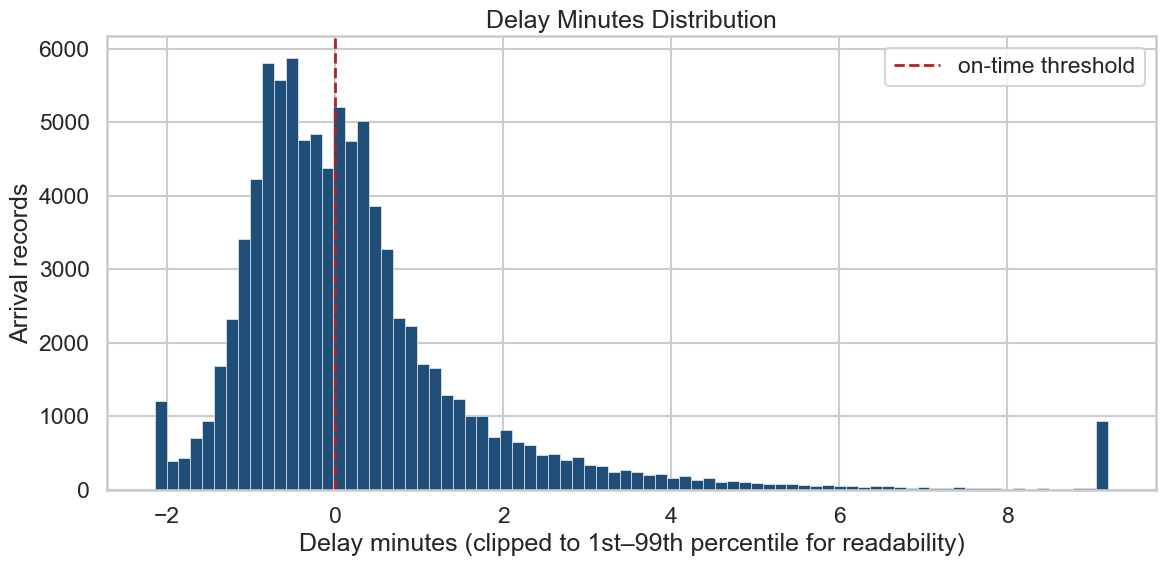

Saved figure to outputs/figures/eda_01_delay_minutes_distribution.png


,quantile,delay_minutes
0,0.00,-147.350000
1,0.01,-2.150000
2,0.05,-1.350000
3,0.25,-0.683333
4,0.50,-0.066667
5,0.75,0.666667
6,0.95,3.166667
7,0.99,9.200000
8,1.00,119.933333


In [6]:
# Use extreme, tail, quartile, and median cut points to summarize both punctual arrivals and large delay outliers.
delay_quantiles = df["delay_minutes"].quantile([0, 0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 1.0])
delay_quantiles_df = delay_quantiles.rename_axis("quantile").reset_index(name="delay_minutes")

lower_clip = delay_quantiles.loc[0.01]
upper_clip = delay_quantiles.loc[0.99]
plot_values = df["delay_minutes"].clip(lower=lower_clip, upper=upper_clip)

fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(plot_values, bins=80, color="#1f4e79", edgecolor="white", linewidth=0.4)
ax.axvline(0, color="#b22222", linestyle="--", linewidth=2, label="on-time threshold")
ax.set_title("Delay Minutes Distribution")
ax.set_xlabel("Delay minutes (clipped to 1st–99th percentile for readability)")
ax.set_ylabel("Arrival records")
ax.legend()
fig.tight_layout()

delay_plot_path = FIGURES_DIR / "eda_01_delay_minutes_distribution.png"
fig.savefig(delay_plot_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved figure to {delay_plot_path.relative_to(ROOT)}")
display(delay_quantiles_df)


## 2.4 Plotting helpers

This section defines the helper functions that keep the grouped delay plots consistent.

In [7]:
# Use explicit weekday ordering so seaborn/bar plots do not fall back to alphabetical day names.
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]
weekend_label_map = {False: "Weekday", True: "Weekend"}


def build_delay_summary(
    data: pd.DataFrame,
    column: str,
    order: list | None = None,
    label_map: dict | None = None,
    sort_desc: bool = False,
) -> pd.DataFrame:
    summary = (
        data.groupby(column, observed=False)
        .agg(
            rows=("delayed", "size"),
            delay_rate=("delayed", "mean"),
            mean_delay_minutes=("delay_minutes", "mean"),
        )
        .reset_index()
    )
    summary = summary[summary["rows"] > 0].copy()
    summary["category"] = summary[column].map(label_map) if label_map else summary[column]

    if order is not None:
        ordered_labels = [label_map.get(item, item) if label_map else item for item in order]
        summary["category"] = pd.Categorical(
            summary["category"],
            categories=ordered_labels,
            ordered=True,
        )
        summary = summary.sort_values("category")
    elif sort_desc:
        summary = summary.sort_values(["delay_rate", "rows"], ascending=[False, False])

    return summary.reset_index(drop=True)


def save_delay_rate_plot(
    summary: pd.DataFrame,
    title: str,
    filename: str,
    x_label: str,
    rotate: int = 0,
    figsize: tuple[float, float] = (12, 6),
    annotate_counts: bool = False,
) -> Path:
    fig, ax = plt.subplots(figsize=figsize)
    category_labels = summary["category"].astype(str).tolist()
    positions = list(range(len(summary)))
    bars = ax.bar(positions, summary["delay_rate"], color="#1f4e79", width=0.8)
    ax.set_xticks(positions)
    ax.set_xticklabels(category_labels)
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.set_title(title)
    ax.set_xlabel(x_label)
    ax.set_ylabel("Delay rate")
    ax.set_ylim(0, max(0.05, summary["delay_rate"].max() * 1.15))
    if rotate:
        plt.setp(ax.get_xticklabels(), rotation=rotate, ha="right")
    if annotate_counts and len(summary) <= 10:
        for patch, row in zip(bars, summary.itertuples(index=False)):
            ax.text(
                patch.get_x() + patch.get_width() / 2,
                patch.get_height(),
                f"n={row.rows:,}",
                ha="center",
                va="bottom",
                fontsize=9,
            )
    fig.tight_layout()
    output_path = FIGURES_DIR / filename
    fig.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.show()
    return output_path


## 2.5 Temporal and operational delay rate views

This section looks at how delays are distributed according to temporal and operational features:
- Season 
- Hour
- Day of the week
- Month
- Whether the day is a weekend
- Station
- Train type
- Line
- Operator

**Figures produced in this subsection:** `eda_02_delay_rate_by_season_window.png` through `eda_10_delay_rate_by_operator.png`


In [8]:
# Drive the repeated bar plots from one spec list so every temporal/operational view uses the same summary and save logic.
rate_plot_specs = [
    {
        "column": "season_window",
        "title": "Delay Rate by Seasonal Window",
        "filename": "eda_02_delay_rate_by_season_window.png",
        "x_label": "Seasonal window",
        "order": season_order,
        "label_map": None,
        # rotate controls readability of the horizontal axis labels, while figsize makes dense categories easier to read in the exported report figure.
        "rotate": 15,
        "figsize": (12, 6),
        "sort_desc": False,
    },
    {
        "column": "scheduled_arrival_hour",
        "title": "Delay Rate by Scheduled Arrival Hour",
        "filename": "eda_03_delay_rate_by_hour.png",
        "x_label": "Scheduled arrival hour",
        "order": list(range(24)),
        "label_map": None,
        "rotate": 0,
        "figsize": (14, 6),
        "sort_desc": False,
    },
    {
        "column": "scheduled_arrival_weekday_name",
        "title": "Delay Rate by Day of Week",
        "filename": "eda_04_delay_rate_by_weekday.png",
        "x_label": "Day of week",
        "order": weekday_order,
        "label_map": None,
        "rotate": 20,
        "figsize": (12, 6),
        "sort_desc": False,
    },
    {
        "column": "scheduled_arrival_month",
        "title": "Delay Rate by Calendar Month",
        "filename": "eda_05_delay_rate_by_month.png",
        "x_label": "Calendar month",
        "order": sorted(df["scheduled_arrival_month"].unique()),
        "label_map": None,
        "rotate": 0,
        "figsize": (10, 6),
        "sort_desc": False,
    },
    {
        "column": "is_weekend",
        "title": "Delay Rate by Weekend Indicator",
        "filename": "eda_06_delay_rate_by_weekend_indicator.png",
        "x_label": "Weekend indicator",
        "order": [False, True],
        "label_map": weekend_label_map,
        "rotate": 0,
        "figsize": (8, 6),
        "sort_desc": False,
    },
    {
        "column": "stop_name",
        "title": "Delay Rate by Station",
        "filename": "eda_07_delay_rate_by_station.png",
        "x_label": "Station",
        "order": None,
        "label_map": None,
        "rotate": 20,
        "figsize": (12, 6),
        "sort_desc": True,
    },
    {
        "column": "train_type",
        "title": "Delay Rate by Train Type",
        "filename": "eda_08_delay_rate_by_train_type.png",
        "x_label": "Train type",
        "order": None,
        "label_map": None,
        "rotate": 0,
        "figsize": (12, 6),
        "sort_desc": True,
    },
    {
        "column": "line_name",
        "title": "Delay Rate by Line Name",
        "filename": "eda_09_delay_rate_by_line_name.png",
        "x_label": "Line name",
        "order": None,
        "label_map": None,
        "rotate": 65,
        "figsize": (16, 8),
        "sort_desc": True,
    },
    {
        "column": "operator",
        "title": "Delay Rate by Operator",
        "filename": "eda_10_delay_rate_by_operator.png",
        "x_label": "Operator",
        "order": None,
        "label_map": None,
        "rotate": 0,
        "figsize": (8, 6),
        "sort_desc": True,
    },
]


,season_window,rows,delay_rate,mean_delay_minutes,category
0,Winter (Jan window),25052,0.469583,0.285442,Winter (Jan window)
1,Spring (Apr window),24769,0.468731,0.322391,Spring (Apr window)
2,Summer (Jul window),16001,0.460284,0.439741,Summer (Jul window)
3,Autumn (Oct window),24996,0.492839,0.430520,Autumn (Oct window)


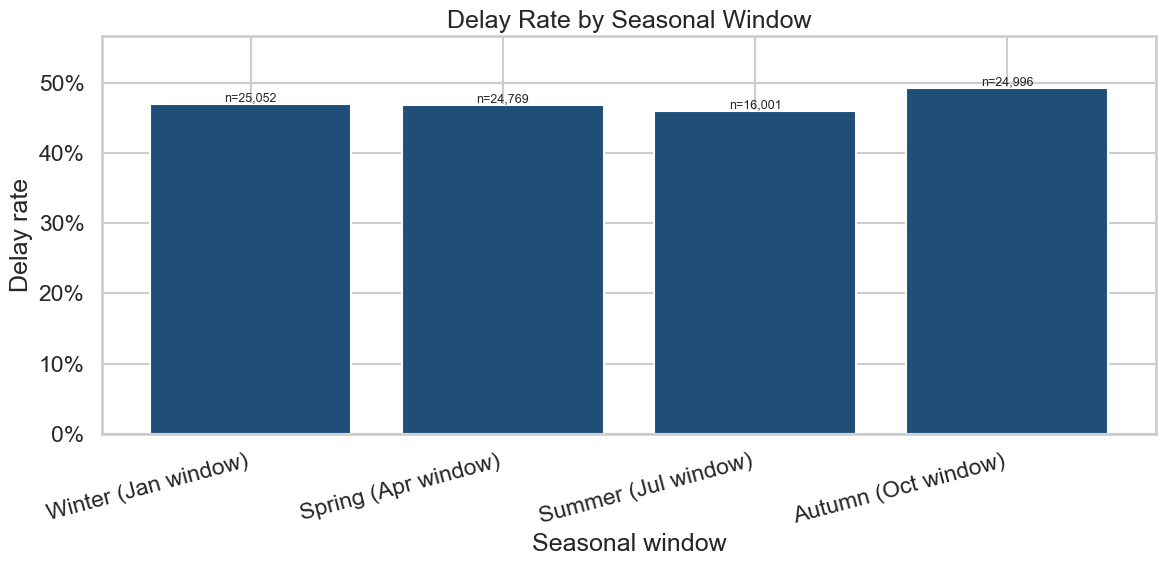

,scheduled_arrival_hour,rows,delay_rate,mean_delay_minutes,category
0,0,2271,0.623074,1.228739,0
1,1,933,0.650589,1.453162,1
2,2,282,0.539007,1.038830,2
3,3,142,0.795775,0.624883,3
4,4,213,0.661972,0.962050,4
5,5,2206,0.611967,0.615481,5
6,6,4749,0.542851,0.494746,6
7,7,4998,0.566226,0.667053,7
8,8,5070,0.524063,0.467143,8
9,9,4881,0.440484,0.133176,9


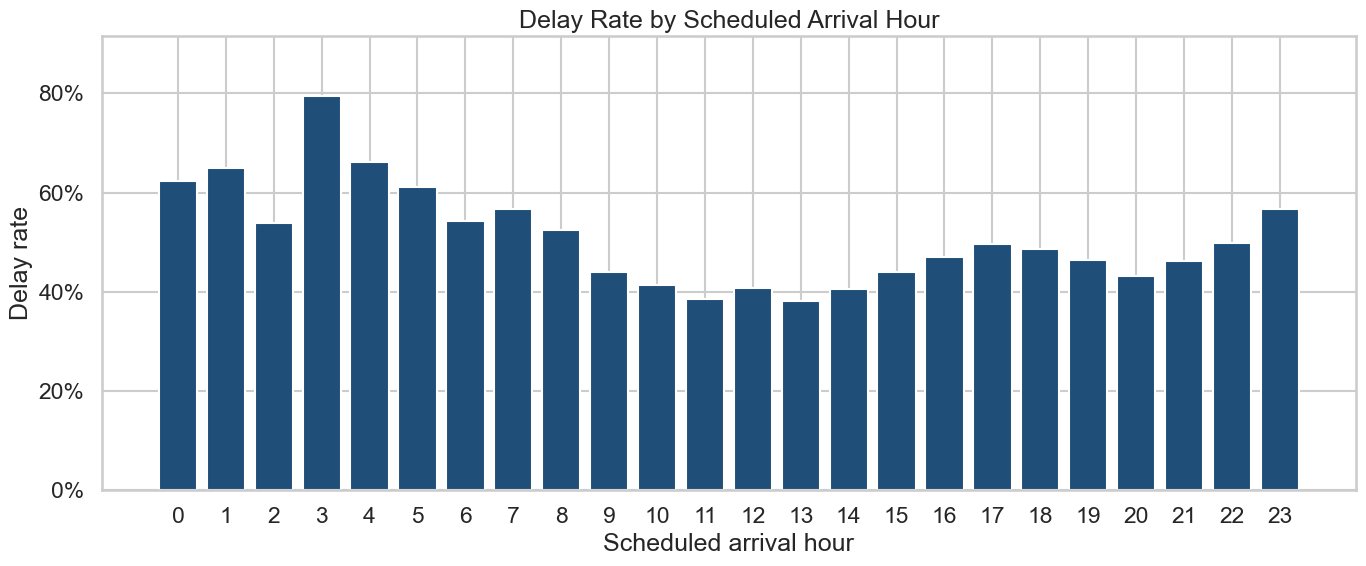

,scheduled_arrival_weekday_name,rows,delay_rate,mean_delay_minutes,category
0,Monday,12275,0.507862,0.485226,Monday
1,Tuesday,13737,0.485841,0.389566,Tuesday
2,Wednesday,15280,0.485471,0.457357,Wednesday
3,Thursday,13973,0.507980,0.482333,Thursday
4,Friday,12482,0.477167,0.362487,Friday
5,Saturday,12464,0.425144,0.170063,Saturday
6,Sunday,10607,0.412841,0.118211,Sunday


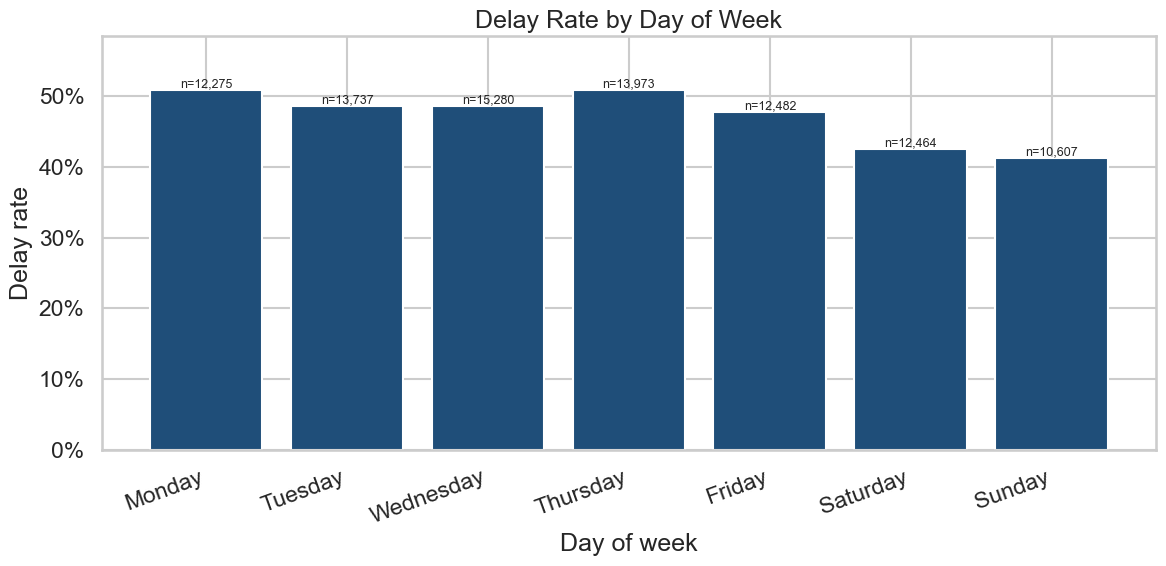

,scheduled_arrival_month,rows,delay_rate,mean_delay_minutes,category
0,1,25052,0.469583,0.285442,1
1,4,24744,0.468679,0.322471,4
2,5,25,0.520000,0.243333,5
3,7,16001,0.460284,0.439741,7
4,10,24996,0.492839,0.430520,10


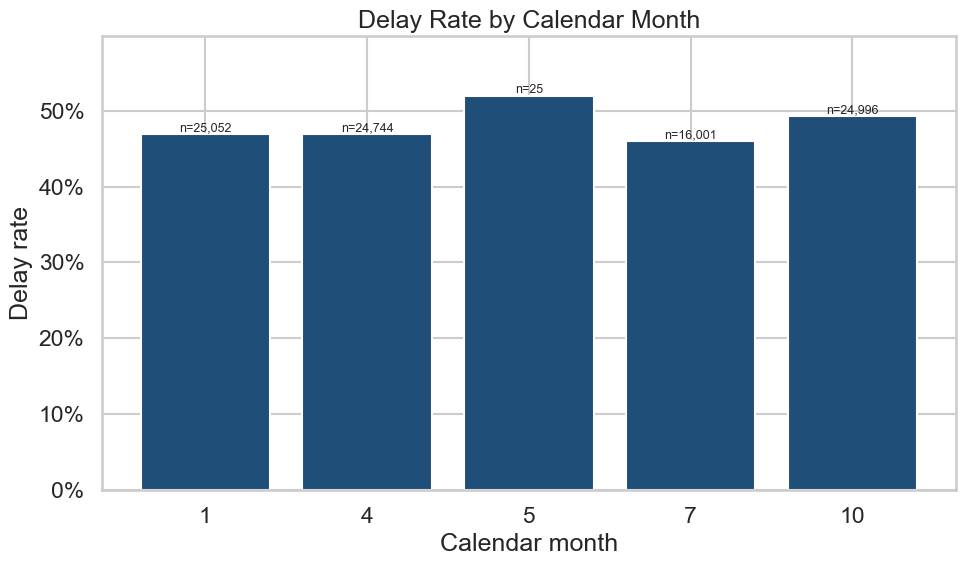

,is_weekend,rows,delay_rate,mean_delay_minutes,category
0,False,67747,0.492716,0.436333,Weekday
1,True,23071,0.419488,0.146224,Weekend


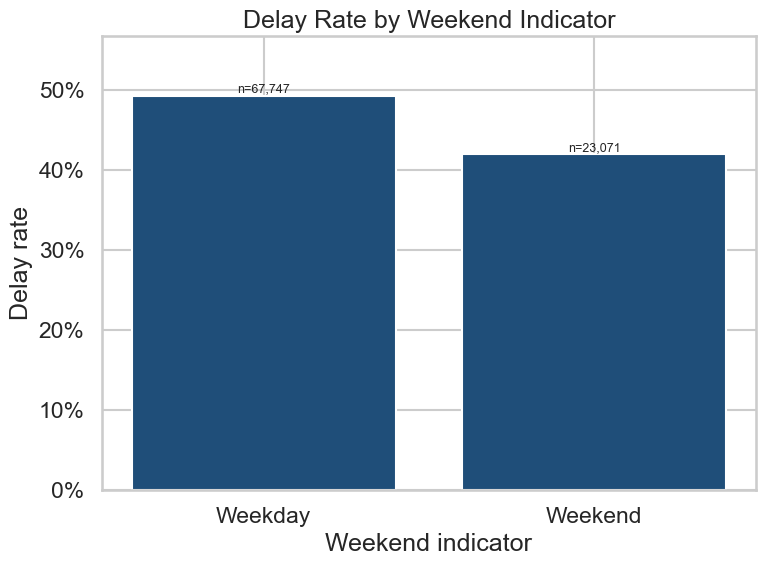

,stop_name,rows,delay_rate,mean_delay_minutes,category
0,Lausanne-Chauderon,10749,0.558005,0.160502,Lausanne-Chauderon
1,Romanel-sur-Lausanne,10749,0.540888,0.311178,Romanel-sur-Lausanne
2,Lausanne,63942,0.475493,0.471051,Lausanne
3,Lausanne-Flon,5378,0.156564,-0.419530,Lausanne-Flon


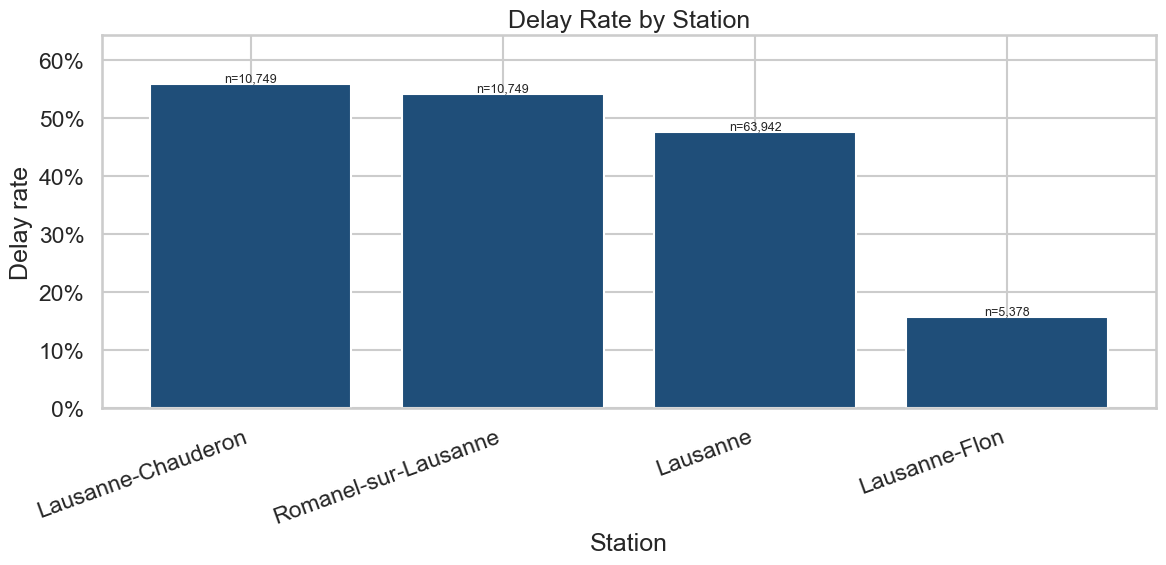

,train_type,rows,delay_rate,mean_delay_minutes,category
0,EXT,134,0.686567,3.251368,EXT
1,S,4755,0.635962,0.881013,S
2,RE,8865,0.632487,0.834247,RE
3,SN,395,0.526582,0.447637,SN
4,TGV,610,0.508197,4.870055,TGV
5,R,54082,0.492437,0.304202,R
6,EC,715,0.488112,1.474266,EC
7,IC,8381,0.362487,0.177686,IC
8,IR,12881,0.294853,-0.095444,IR


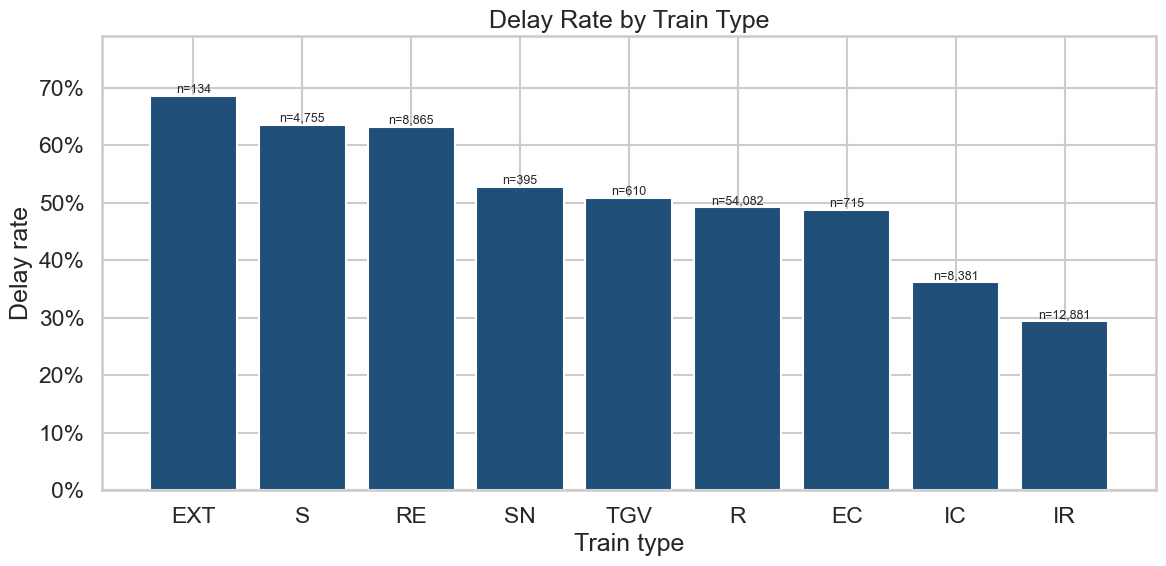

,line_name,rows,delay_rate,mean_delay_minutes,category
0,R,3,1.000000,2.061111,R
1,EXT15,1,1.000000,26.666667,EXT15
2,EXT33,1,1.000000,7.950000,EXT33
3,EXT,131,0.687023,3.070483,EXT
4,S40,2266,0.675199,0.888732,S40
5,R2,4495,0.643382,0.529140,R2
6,RE33,8709,0.635090,0.847503,RE33
7,S41,2489,0.600241,0.873986,S41
8,R8,3908,0.595957,0.746981,R8
9,R9,4728,0.565567,0.604963,R9


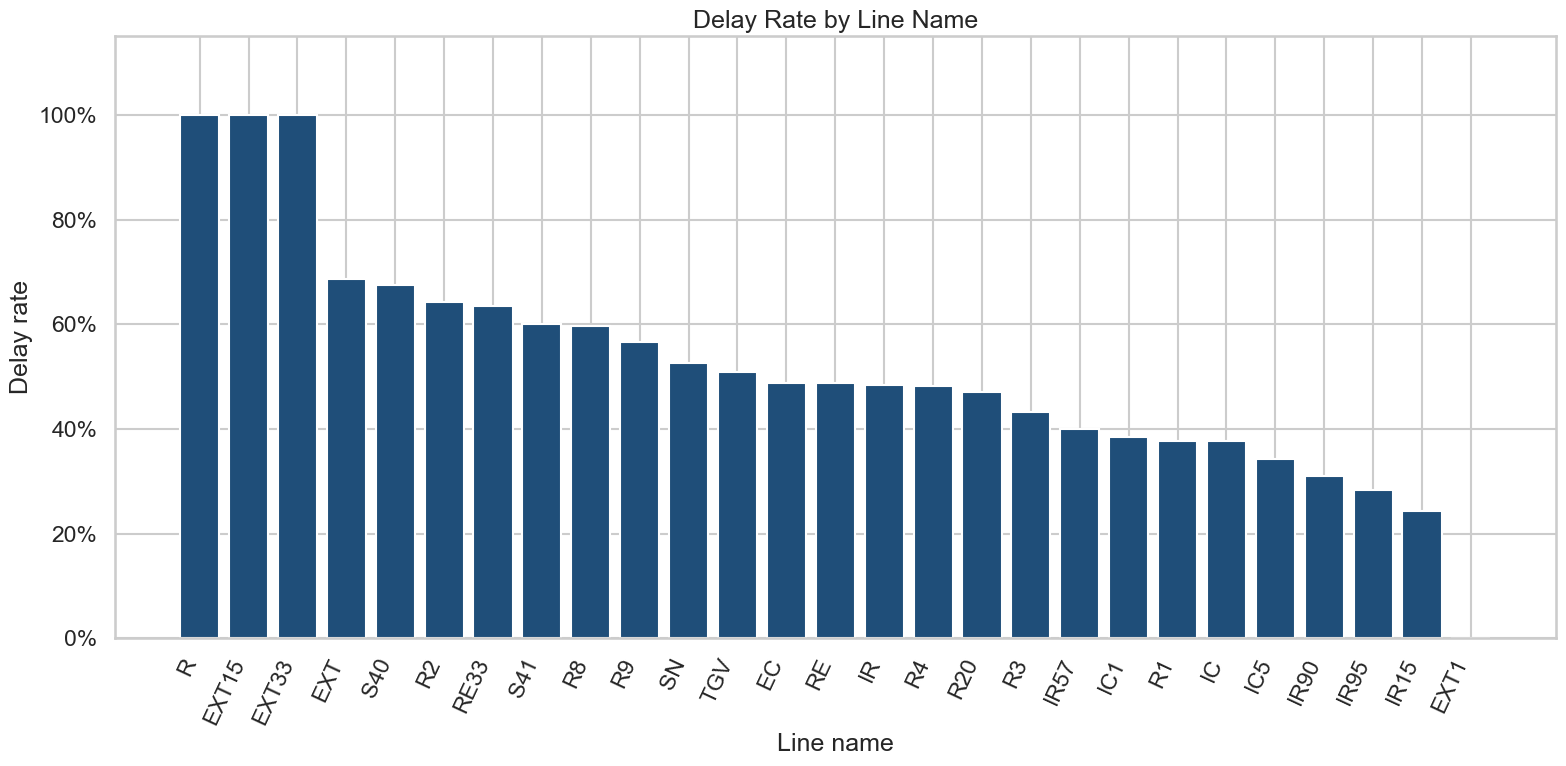

,operator,rows,delay_rate,mean_delay_minutes,category
0,SBB,63942,0.475493,0.471051,SBB
1,LEB,26876,0.470829,0.104697,LEB


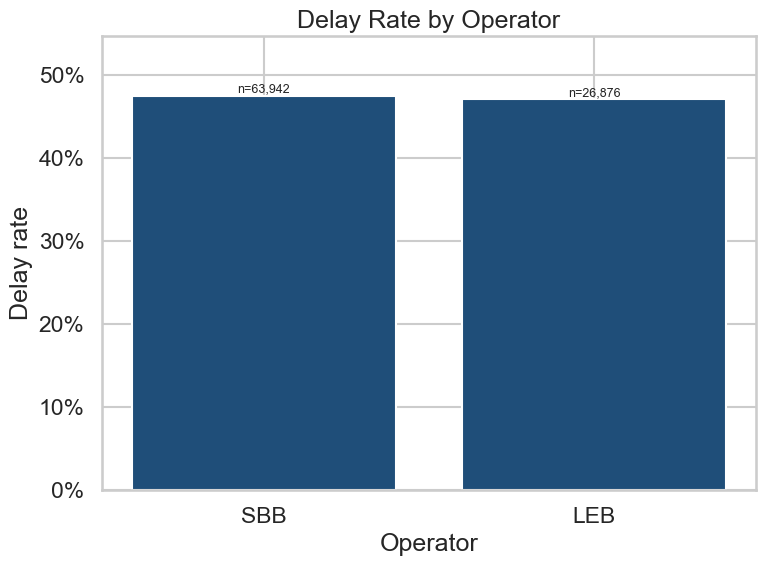

Saved temporal/operational figures:
- outputs/figures/eda_02_delay_rate_by_season_window.png
- outputs/figures/eda_03_delay_rate_by_hour.png
- outputs/figures/eda_04_delay_rate_by_weekday.png
- outputs/figures/eda_05_delay_rate_by_month.png
- outputs/figures/eda_06_delay_rate_by_weekend_indicator.png
- outputs/figures/eda_07_delay_rate_by_station.png
- outputs/figures/eda_08_delay_rate_by_train_type.png
- outputs/figures/eda_09_delay_rate_by_line_name.png
- outputs/figures/eda_10_delay_rate_by_operator.png


In [9]:
temporal_operational_summaries = {}
saved_rate_plots = []

for spec in rate_plot_specs:
    summary = build_delay_summary(
        df,
        column=spec["column"],
        order=spec["order"],
        label_map=spec["label_map"],
        sort_desc=spec["sort_desc"],
    )
    temporal_operational_summaries[spec["column"]] = summary
    display(summary)
    saved_rate_plots.append(
        save_delay_rate_plot(
            summary,
            title=spec["title"],
            filename=spec["filename"],
            x_label=spec["x_label"],
            rotate=spec["rotate"],
            figsize=spec["figsize"],
            annotate_counts=True,
        )
    )

print("Saved temporal/operational figures:")
for path in saved_rate_plots:
    print(f"- {path.relative_to(ROOT)}")
